In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import os


In [2]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

def load_data(data_path, img_size=(48, 48)):
    X, y = [], []
    emotion_labels = {emotion: idx for idx, emotion in enumerate(os.listdir(data_path))}
    for label, emotion_id in emotion_labels.items():
        folder_path = os.path.join(data_path, label)
        for img_file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(emotion_id)
    X = np.array(X).reshape(-1, img_size[0], img_size[1], 1) / 255.0  # Normalize
    y = to_categorical(y, num_classes=len(emotion_labels))
    return X, y, emotion_labels

data_path = "C:/Users/Lahiru/Emotion recognition system/DATA/train"  
X, y, emotion_labels = load_data(data_path)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded successfully")
print("Emotion labels:", emotion_labels)


Data loaded successfully
Emotion labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [4]:
X_train.shape

(74374, 48, 48, 1)

In [5]:
X_test.shape

(18594, 48, 48, 1)

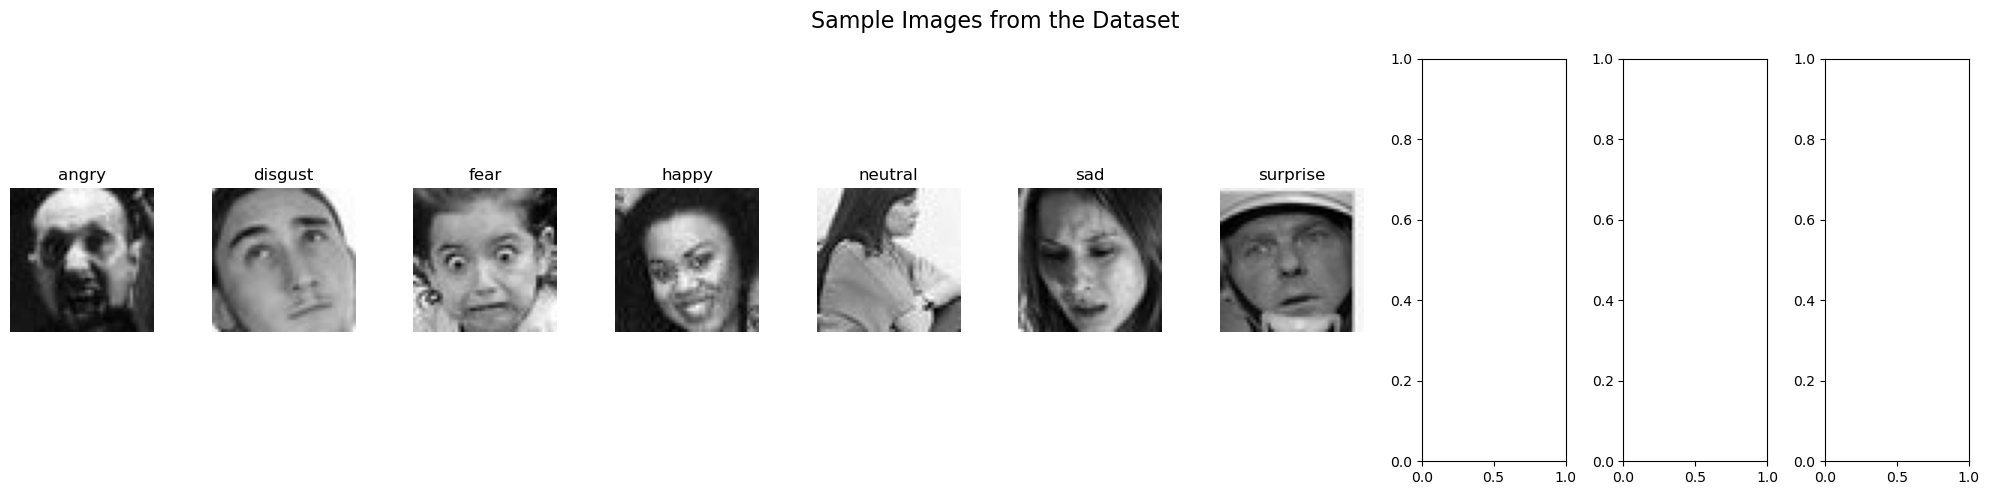

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

# Function to visualize some images from the dataset
def visualize_images(data_path, num_images=10, img_size=(48, 48)):
    emotion_labels = os.listdir(data_path)
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    fig.suptitle("Sample Images from the Dataset", fontsize=16)

    for i, emotion in enumerate(emotion_labels):
        if i >= num_images:
            break
        folder_path = os.path.join(data_path, emotion)
        img_file = os.listdir(folder_path)[0]  # Take the first image from each folder
        img_path = os.path.join(folder_path, img_file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, img_size)
            axes[i].imshow(img_resized, cmap="gray")
            axes[i].set_title(emotion)
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Path to your dataset
data_path = "C:/Users/Lahiru/Emotion recognition system/DATA/train"  # Update this path
visualize_images(data_path)


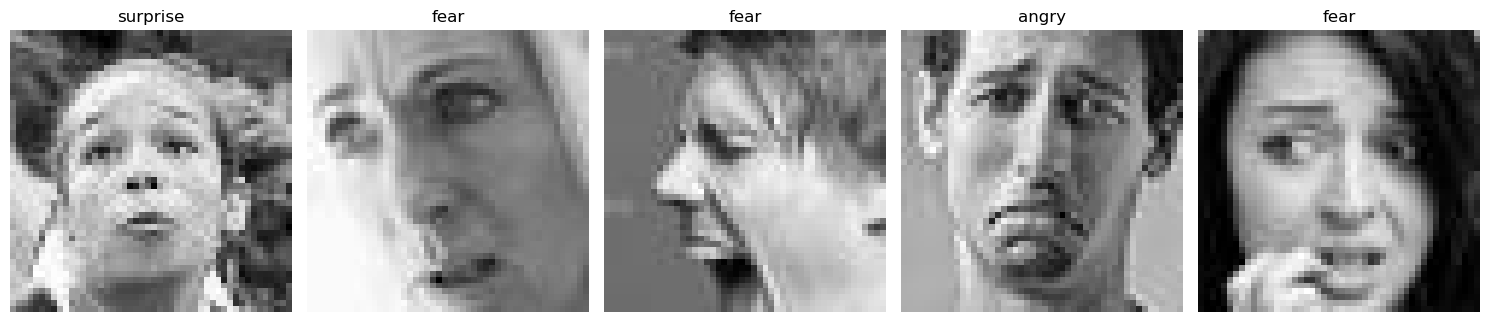

In [7]:
import random

# Function to display random images with their labels
def display_random_images(data_path, num_images=5, img_size=(48, 48)):
    emotion_labels = os.listdir(data_path)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        emotion = random.choice(emotion_labels)
        folder_path = os.path.join(data_path, emotion)
        img_file = random.choice(os.listdir(folder_path))
        img_path = os.path.join(folder_path, img_file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, img_size)
            axes[i].imshow(img_resized, cmap="gray")
            axes[i].set_title(emotion)
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Path to your dataset
display_random_images(data_path)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, Input, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(train_images)  


def residual_block(x, filters, kernel_size=(3, 3), stride=1):
    shortcut = x
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or x.shape[-1] != shortcut.shape[-1]:
        shortcut = Conv2D(filters, kernel_size=(1, 1), strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_resnet(input_shape=(48, 48, 1), num_classes=7):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (7, 7), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # Residual blocks
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 512, stride=2)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_resnet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 24,    │      3,200 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 24,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 12, 12,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 12, 12,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 12,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 12,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 6, 6, 128) │     73,856 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 6, 128) │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 6, 6, 128) │    147,584 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 6, 6, 128) │      8,320 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 6, 128) │        512 │ conv2d_4[0][0]  

 Total params: 4,911,751 (18.74 MB)

 Trainable params: 4,905,991 (18.71 MB)

 Non-trainable params: 5,760 (22.50 KB)

In [9]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)
model.save('emotion_recognition.h5')


Epoch 1/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 382s 159ms/step - accuracy: 0.4764 - loss: 1.4556 - val_accuracy: 0.4080 - val_loss: 1.6046
Epoch 2/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 367s 158ms/step - accuracy: 0.5954 - loss: 1.1581 - val_accuracy: 0.5746 - val_loss: 1.2114
Epoch 3/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 367s 158ms/step - accuracy: 0.6340 - loss: 1.0346 - val_accuracy: 0.6164 - val_loss: 1.0841
Epoch 4/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 363s 156ms/step - accuracy: 0.6596 - loss: 0.9558 - val_accuracy: 0.5727 - val_loss: 1.2266
Epoch 5/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 365s 157ms/step - accuracy: 0.6973 - loss: 0.8582 - val_accuracy: 0.6157 - val_loss: 1.1115
Epoch 6/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 365s 157ms/step - accuracy: 0.7350 - loss: 0.7473 - val_accuracy: 0.6279 - val_loss: 1.1239
Epoch 7/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 376s 162ms/step - accuracy: 0.7828 - loss: 0.6142 - val_accuracy: 0.6298 - val_loss: 1.1822
Epoch 8/20
2325/2325 ━━━━━━━━━━━━━━━━━━━━ 388s 167ms/step - ac

In [ ]:
def real_time_emotion_recognition(emotion_labels):
    model = tf.keras.models.load_model("emotion_recognition_resnet.h5")
    emotion_labels_rev = {idx: emotion for emotion, idx in emotion_labels.items()}  # Reverse mapping
    cap = cv2.VideoCapture(0)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        for (x, y, w, h) in faces:
            roi = gray[y:y+h, x:x+w]
            roi = cv2.resize(roi, (48, 48))
            roi = roi.reshape(1, 48, 48, 1) / 255.0
            prediction = model.predict(roi)
            emotion = emotion_labels_rev.get(np.argmax(prediction), "Unknown")  # Safe lookup

            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            cv2.putText(frame, emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

        cv2.imshow("Emotion Recognition", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

# Call the function with emotion_labels
emotion_labels = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}  
real_time_emotion_recognition(emotion_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━

In [11]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


582/582 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.6163 - loss: 2.5240
Test Accuracy: 62.01%
Test Loss: 2.5231


582/582 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.38      0.39      1271
           1       0.28      0.14      0.19       658
           2       0.39      0.35      0.37       968
           3       0.82      0.81      0.81      5799
           4       0.59      0.72      0.65      5869
           5       0.44      0.36      0.39      2413
           6       0.66      0.52      0.59      1616

    accuracy                           0.62     18594
   macro avg       0.51      0.47      0.48     18594
weighted avg       0.61      0.62      0.61     18594



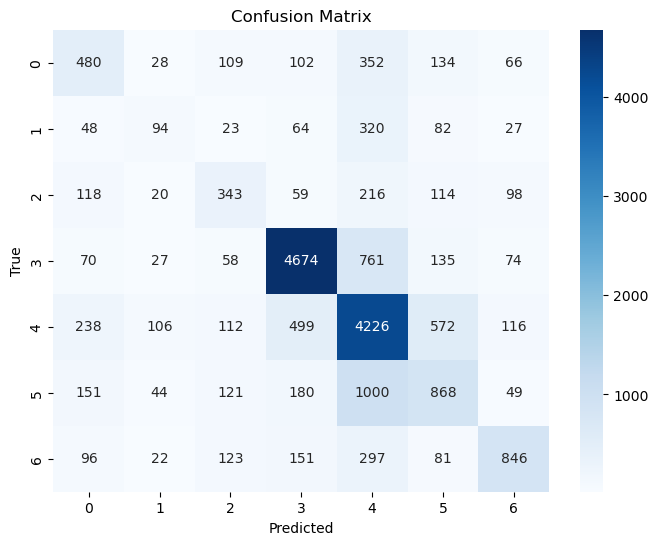

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming `emotion_labels` is a dictionary mapping class indices to labels
# For example: emotion_labels = {0: "Happy", 1: "Sad", 2: "Angry", ...}

# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Ensure target_names are strings
target_names = [str(label) for label in emotion_labels.values()]

# Classification report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

# Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
